<a href="https://colab.research.google.com/github/IshanRavishankar15/23FE10CSE00641-ML/blob/main/Lab7_Random_Forest_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Lab 7
##Random Forest Classification

Aim: Implement Random forest Classification on the Parkinsons dataset

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# load dataset
df = pd.read_csv('parkinsons.csv')
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
# target distribution
df['status'].value_counts()

,count
status,
1,147
0,48


In [ ]:
# drop name column
df = df.drop(['name'], axis=1)

In [ ]:
# split X and y
X = df.drop('status', axis=1)
y = df['status']

In [ ]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# predictions
y_pred = rf.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1])

In [ ]:
# accuracy
accuracy_score(y_test, y_pred)

0.9487179487179487

In [ ]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



In [ ]:
# confusion matrix
confusion_matrix(y_test, y_pred)

array([[ 5,  2],
       [ 0, 32]])

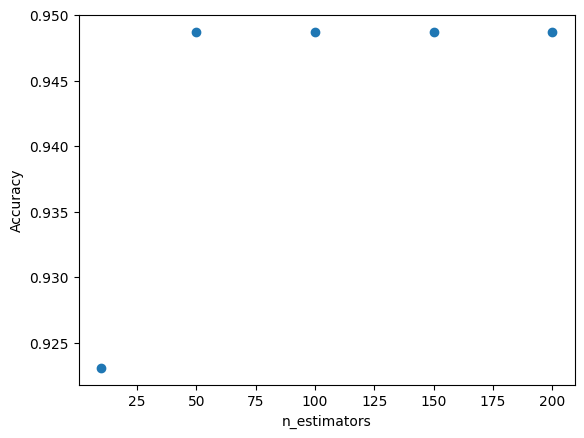

In [ ]:
# loop n_estimators with scatter
trees = [10, 50, 100, 150, 200]
acc_trees = []

for t in trees:
    model = RandomForestClassifier(n_estimators=t, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc_trees.append(accuracy_score(y_test, pred))

plt.scatter(trees, acc_trees)
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()

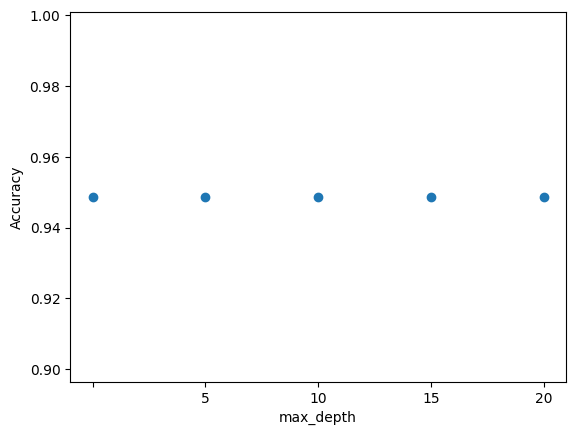

In [ ]:
# loop max_depth with scatter
depths = [None, 5, 10, 15, 20]
acc_depth = []

for d in depths:
    model = RandomForestClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc_depth.append(accuracy_score(y_test, pred))

plt.scatter(range(len(depths)), acc_depth)
plt.xticks(range(len(depths)), depths)
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.show()

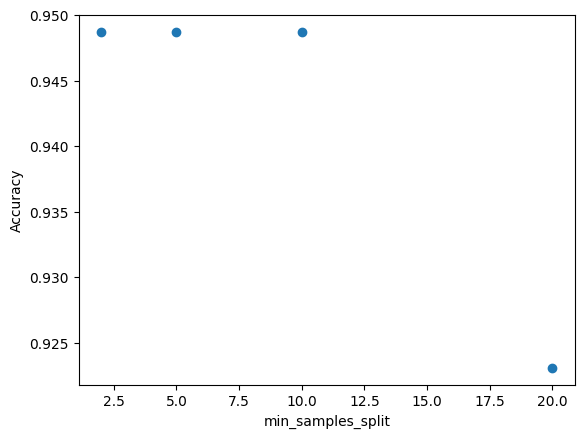

In [ ]:
# loop min_samples_split with scatter
splits = [2, 5, 10, 20]
acc_split = []

for s in splits:
    model = RandomForestClassifier(min_samples_split=s, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc_split.append(accuracy_score(y_test, pred))

plt.scatter(splits, acc_split)
plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# grid search setup
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [ ]:
# run grid search
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]})

In [ ]:
# best parameters
grid.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

In [ ]:
# best model
best_model = grid.best_estimator_

In [ ]:
# predictions best model
y_pred_best = best_model.predict(X_test)

In [ ]:
# best accuracy
accuracy_score(y_test, y_pred_best)

0.9487179487179487

In [ ]:
# best classification report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



In [ ]:
# best confusion matrix
confusion_matrix(y_test, y_pred_best)

array([[ 5,  2],
       [ 0, 32]])